# Научно-исследовательская работа
## Сжатие текста с потерями на основе технологий машинного обучения

**Студент:** Кузнецов Степан Андреевич

**Группа:** РТ5-61Б

**Дата:** 01.06.2026

## 1. Постановка задачи

**Цель:** Построение специализированной модели машинного обучения сжатия для определенного русского текста и сравнение объема модели с сжатым текстом, обработанным традиционными архиваторами.

**Тип задачи:** Суммаризация как компрессия.

**Источник данных:** Russian NLP Datasets - Lenta Ru Dataset

## 2. Импорт необходимых библиотек

Импортируются все необходимые модули: библиотеки для работы с данными (numpy, pandas), визуализации (matplotlib, seaborn) и машинного обучения (python). Также задаётся стиль графиков.

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gzip
import bz2
import torch
import torch.nn as nn
import torch.optim as optim
from rouge_score import rouge_scorer

## 3. Загрузка данных 

Исходный датасет, откуда мы выберем одну колонку.

In [23]:
df = pd.read_csv("2007-04-lenta.ru.csv", sep=',')

print(f"Размер датасета: {df.shape}")
print("\nПервые 5 строк:")
df.head()

Размер датасета: (2891, 6)

Первые 5 строк:


,datetime,url,edition,topics,title,text
0,2007-04-01 12:00:00,https://lenta.ru/news/2007/04/01/bury/,NaN,Бывший СССР,Звиад Гамсахурдия похоронен в Тбилиси,В Тбилиси прошла церемония перезахоронения пер...
1,2007-04-01 12:00:00,https://lenta.ru/news/2007/04/01/choice/,NaN,Культура,В Лос-Анджелесе наградили детских кумиров,В Лос-Анджелесе в субботу вечером (воскресенье...
2,2007-04-01 12:00:00,https://lenta.ru/news/2007/04/01/cska/,NaN,Спорт,"ЦСКА обыграл ""Ак Барс"" и сократил счет в полуф...",В Москве состоялся третий матч полуфинальной с...
3,2007-04-01 12:00:00,https://lenta.ru/news/2007/04/01/debt/,NaN,Россия,Бельгия припомнила России дореволюционные долги,Бельгийские власти намерены в суде добиваться ...
4,2007-04-01 12:00:00,https://lenta.ru/news/2007/04/01/discs/,NaN,Наука и техника,Михаил Фрадков выгнал диски из палаток,Премьер-министр Михаил Фрадков подписал постан...


In [59]:
# Берём 4 новости из колонки 'text'
texts = df['text'].sample(n=4, random_state=54).tolist()

texts = [t[:300] for t in texts]

# Проверяем результат
print(f"\nОтобрано новостей: {len(texts)}")
print("\n4 отобранных новостей:")
for i, text in enumerate(texts):
    print(f"{i+1}. {text}")


Отобрано новостей: 4

4 отобранных новостей:
1. В воскресенье в Калифорнии произошла автокатастрофа, приведшая к обрушению части транспортной эстакады на участке автодороги Сан-Франциско - Окленд, сообщает Associated Press. Секция моста обрушилась после того, как на ней перевернулся бензовоз. В результате начавшегося пожара водитель машины получи
2. Акцию памяти Бориса Ельцина готовят в Москве Московская Хельсинкская группа и движение "За права человека", сообщает "Эхо Москвы". Правозащитный митинг "Солидарность в борьбе за конституционные права и свободы человека и гражданина" пройдет в четверг, 26 апреля, с 18 до 20 часов в Новопушкинском скв
3. Председатель наблюдательного совета Siemens Хенрих фон Пирер (Heinrich v. Pierer) 25 апреля 2007 года уйдет в отставку. Об этом говорится в официальном пресс-релизе Siemens. Наблюдательному совету будет предложено утвердить на эту должность председателя комитета по аудиту Герхарда Kромме (Gerhard Cr
4. В Москве состоялся третий матч полуфина

## 4. Разведочный анализ данных

## Описание набора данных

### Источник
Данные взяты из Russian NLP Datasets: [Russian NLP Datasets](https://github.com/buriy/russian-nlp-datasets/releases). Они содержат материалы новостного сайта "Лента Ру".

Нас интересует только столбец "text", откуда мы отобрали 4 строки, после чего оставили только 300 первых символов. Если говорить конкретно, новости выбирались из файла '2007-04-lenta.ru.csv'.

### Общая характеристика
- **Количество образцов**: 4.
- **Средняя длина фрагмента:** 300 символ.
- **Минимальная длина фрагмента:** 300 символ.
- **Максимальная длина фрагмента:** 300 символ.

### Распределение длин заголовков

LSTM-архитектура, к которой мы прибегнем, плохо работает с длинными текстами. Перепроверим, что новостные заголовки действительно относительно "дружелюбны".

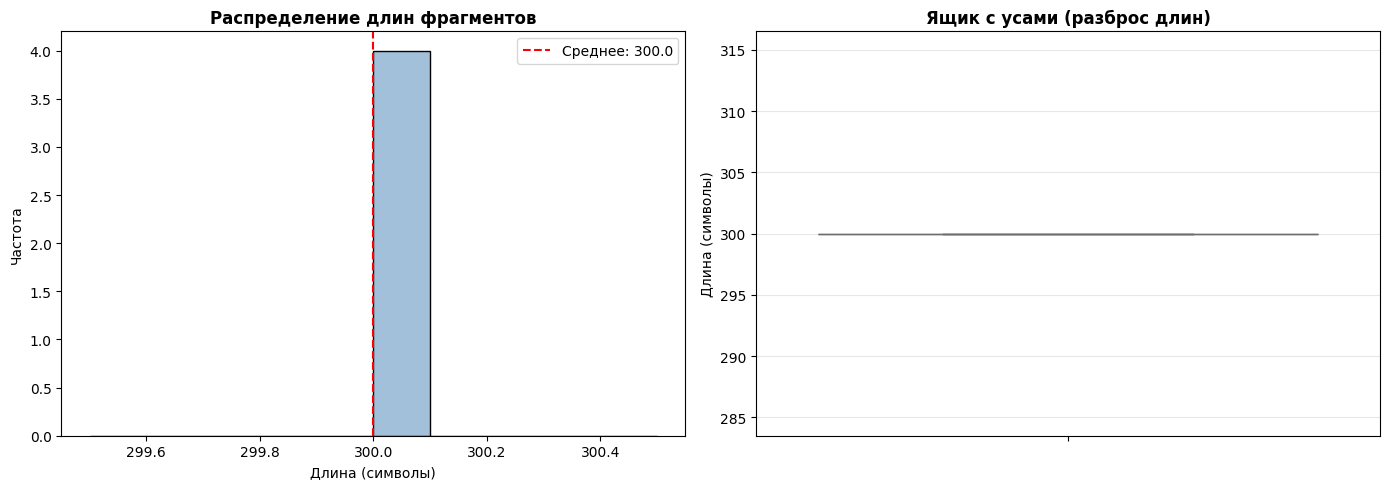

In [60]:
# DataFrame для удобства работы с seaborn
df_lengths = pd.DataFrame({
    'длина_символы': [len(t) for t in texts],
    'индекс': range(1, len(texts)+1)
})

# График 1: Гистограмма распределения длин
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
sns.histplot(data=df_lengths, x='длина_символы', bins=10, 
             kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Распределение длин фрагментов', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Длина (символы)')
axes[0].set_ylabel('Частота')
axes[0].axvline(x=df_lengths['длина_символы'].mean(), 
                color='red', linestyle='--', label=f'Среднее: {df_lengths["длина_символы"].mean():.1f}')
axes[0].legend()

# Boxplot
sns.boxplot(data=df_lengths, y='длина_символы', ax=axes[1], color='lightcoral')
axes[1].set_title('Ящик с усами (разброс длин)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Длина (символы)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [61]:
# Опишем статистику
stats = df_lengths['длина_символы'].describe()
print(stats.to_string())

count      4.0
mean     300.0
std        0.0
min      300.0
25%      300.0
50%      300.0
75%      300.0
max      300.0


## 5. Оценка базовой сжимаемости

Прежде чем приступать к построению модели, оценим, насколько эффективно каждый фрагмент сжимается средствами gzip. Это будет baseline - показатель, относительно которого будет производиться сравнение эффективности lossy-компрессии нашим методом.

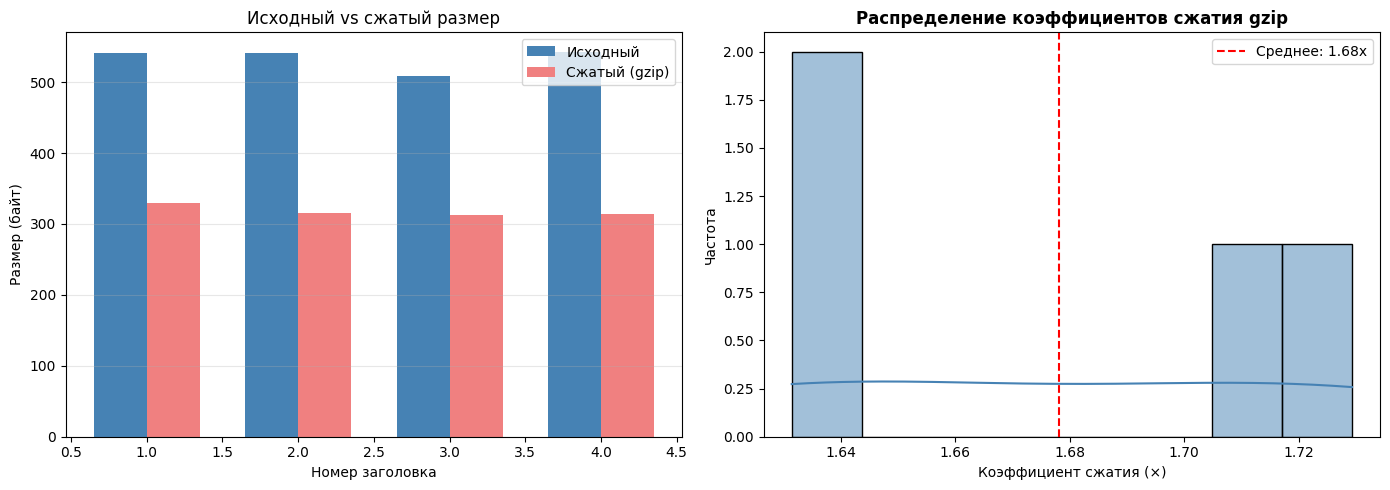

In [62]:
import gzip

compression_ratios = []
original_sizes = []
compressed_sizes = []

for text in texts:
    orig = len(text.encode('utf-8'))
    comp = len(gzip.compress(text.encode('utf-8')))
    original_sizes.append(orig)
    compressed_sizes.append(comp)
    compression_ratios.append(orig / comp)

# DataFrame для визуализации
df_compress = pd.DataFrame({
    'индекс': range(1, len(titles)+1),
    'исходный_размер': original_sizes,
    'сжатый_размер': compressed_sizes,
    'коэффициент_сжатия': compression_ratios
})

# График: Сравнение исходного и сжатого размеров
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Столбчатая диаграмма
x = range(1, len(titles)+1)
width = 0.35
axes[0].bar([i - width/2 for i in x], original_sizes, width, label='Исходный', color='steelblue')
axes[0].bar([i + width/2 for i in x], compressed_sizes, width, label='Сжатый (gzip)', color='lightcoral')
axes[0].set_xlabel('Номер заголовка')
axes[0].set_ylabel('Размер (байт)')
axes[0].set_title('Исходный vs сжатый размер')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Гистограмма коэффициентов сжатия
sns.histplot(df_compress['коэффициент_сжатия'], bins=8, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Распределение коэффициентов сжатия gzip', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Коэффициент сжатия (×)')
axes[1].set_ylabel('Частота')
axes[1].axvline(x=df_compress['коэффициент_сжатия'].mean(), 
                color='red', linestyle='--', label=f'Среднее: {df_compress["коэффициент_сжатия"].mean():.2f}x')
axes[1].legend()

plt.tight_layout()
plt.show()

In [63]:
print(f"Средний коэффициент сжатия gzip: {df_compress['коэффициент_сжатия'].mean():.2f}x")
print(f"Минимальный: {df_compress['коэффициент_сжатия'].min():.2f}x")
print(f"Максимальный: {df_compress['коэффициент_сжатия'].max():.2f}x")

Средний коэффициент сжатия gzip: 1.68x
Минимальный: 1.63x
Максимальный: 1.73x


## 6. Подготовка данных

В данной работе подготовка данных сводится к преобразованию текстовой последовательности в форму, пригодную для обучения LSTM-автокодировщика.

Каждый текст рассматривается как независимый объект. Так как мы a priori планируем использовать переобученную (overfit) модель, разбиение на обучающую и тестовые выборки не требуется. Масштабирование числовых признаков не применяется ввиду их отсутствия.

### Посимвольная токенизация

Выберем в качестве метода токенизации токенизацию по символам (char-level tokenization). Для каждого текста строится словарь уникальных символов, который используется для построения тензора PyTorch.

In [64]:
def prepare_text(text, max_len=300):
    """
    Полный цикл подготовки одного текста:
    - ограничение длины
    - построение словаря
    - преобразование в тензор
    """
    text = text[:max_len]
    chars = sorted(set(text))
    char_to_int = {c: i for i, c in enumerate(chars)}
    int_to_char = {i: c for i, c in enumerate(chars)}
    vocab_size = len(chars)
    data = torch.tensor([char_to_int[c] for c in text], dtype=torch.long).unsqueeze(0)
    return data, char_to_int, int_to_char, vocab_size

# Применение ко всем фрагментам
prepared_data = []
for text in texts:
    data, cti, itc, vs = prepare_text(text)
    prepared_data.append({
        'original': text,
        'data': data,
        'char_to_int': cti,
        'int_to_char': itc,
        'vocab_size': vs,
        'length': len(title)
    })

print(prepared_data[3])

{'original': 'В Москве состоялся третий матч полуфинальной серии плей-офф чемпионата России по хоккею между столичным ЦСКА и казанским "Ак Барсом". Армейцы сумели одержать победу и сократили счет в серии. Поединок на льду армейцев начался так же, как и два матча в Казани – "Ак Барс" открыл счет. Произошло это на ', 'data': tensor([[ 7,  0,  9, 27, 30, 23, 16, 18,  0, 30, 27, 30, 31, 27, 42, 24, 30, 42,
          0, 31, 29, 18, 31, 21, 22,  0, 25, 14, 31, 36,  0, 28, 27, 24, 32, 33,
         21, 26, 14, 24, 39, 26, 27, 22,  0, 30, 18, 29, 21, 21,  0, 28, 24, 18,
         22,  3, 27, 33, 33,  0, 36, 18, 25, 28, 21, 27, 26, 14, 31, 14,  0, 11,
         27, 30, 30, 21, 21,  0, 28, 27,  0, 34, 27, 23, 23, 18, 41,  0, 25, 18,
         19, 17, 32,  0, 30, 31, 27, 24, 21, 36, 26, 38, 25,  0, 13, 12,  8,  5,
          0, 21,  0, 23, 14, 20, 14, 26, 30, 23, 21, 25,  0,  1,  5, 23,  0,  6,
         14, 29, 30, 27, 25,  1,  4,  0,  5, 29, 25, 18, 22, 35, 38,  0, 30, 32,
         25, 18, 24, 21,  0

## 7. Выбор метрик оценки качества

### Обоснование выбора метрик:

1. **Коэффициент сжатия (полный)** — в задачи сжатия это один из важнейших показателей, но не единственный, к максимизации которого мы стремимся. Вычисляется как отношение размера исходного текста (байты) и размера модели текста (байты) и латентного вектора (байты).
2. **Коэффициент сжатия (идеальный)** — то же, что выше, но без учета размера модели. Рассматривается в силу предположения: модель, не заточенная под один конкретный небольшой текст, могла бы поставляться вместе с декодером, делая "архивы" односоставными - передавались бы только латентные векторы. При этом общий вес вектором всех закодированных текстов и модели был бы меньше веса исходных текстов. Метрика демонстрирует потенциал метода при улучшенных вычислительных ресурсах и архитектуре.
3. **Accuracy** — точность, доля верно предсказанных символов восстановленного текста. В идеале высокая точность должна сопровождаться высоким коэффициентом сжатия.
4. **ROUGE-1 F1** — метрика, оценивающая пересечение униграмм (отдельных слов) между оригинальным и восстановленным текстом. Устойчива к небольшим символьным ошибкам и отражает сохранение смысла текста. Является стандартом в задачах генерации и суммаризации.
5. **Baseline** — коэффициент сжатия при использовании gzip. Рассчитывается как отношение размера сжатого текста (байты) к размеру исходного текста (байты).

In [65]:
import gzip
from rouge_score import rouge_scorer

# Для ROUGE
class SimpleTokenizer:
    def tokenize(self, text):
        return text.split()

def calculate_metrics(original_text, reconstructed_text, latent_dim, model_size_bytes):
    # Размеры
    orig_bytes = len(original_text.encode('utf-8'))
    latent_bytes = latent_dim * 4
    
    # 1. Коэффициент сжатия
    compression_ideal = orig_bytes / latent_bytes
    # 2. Идеальный коэффициент сжатия
    compression_full = orig_bytes / (latent_bytes + model_size_bytes)
    
    # 3. Точность
    max_len = max(len(original_text), len(reconstructed_text))
    correct = sum(1 for i in range(min(len(original_text), len(reconstructed_text))) 
                  if original_text[i] == reconstructed_text[i])
    accuracy = correct / max_len if max_len > 0 else 0
    
    # 4. ROUGE
    scorer = rouge_scorer.RougeScorer(['rouge1'], tokenizer=SimpleTokenizer())
    score = scorer.score(original_text, reconstructed_text)
    rouge_f1 = score['rouge1'].fmeasure

    # 5. Baseline
    gzip_bytes = len(gzip.compress(original_text.encode('utf-8')))
    compression_gzip = orig_bytes / gzip_bytes
    
    # Сбор результатов
    results = {
        'orig_bytes': orig_bytes,
        'latent_bytes': latent_bytes,
        'model_bytes': model_size_bytes,
        'gzip_bytes': gzip_bytes,
        'compression_full': compression_full,
        'compression_ideal': compression_ideal,
        'compression_gzip': compression_gzip,
        'accuracy': accuracy,
        'rouge_1': rouge_f1
    }
    
    return results

def print_metrics(metrics):
    print("\n" + "="*60)
    print("МЕТРИКИ")
    print("="*60)
    print(f"Исходный текст: {metrics['orig_bytes']} байт")
    print(f"Латентный вектор: {metrics['latent_bytes']} байт")
    print(f"gzip: {metrics['gzip_bytes']} байт")
    print(f"Полное сжатие (с учётом модели): {metrics['compression_full']:.4f}x")
    print(f"Идеальное сжатие (без учёта модели): {metrics['compression_ideal']:.2f}x")
    print(f"Сжатие gzip: {metrics['compression_gzip']:.2f}x")
    print(f"Размер модели: {metrics['model_bytes'] / (1024*1024):.2f} МБ")
    print(f"Точность (посимвольная): {metrics['accuracy']*100:.1f}%")
    print(f"ROUGE-1 F1: {metrics['rouge_1']:.4f}")
    print("="*60)

## 8. Выбор архитектуры и Baseline

Выбранная архитектура модели - LSTM-автокодировщик.

Автокодировщик состоит из двух частей:

- Энкодер — сжимает входную последовательность символов в латентный вектор фиксированного размера latent_dim. В качестве энкодера используется двунаправленная LSTM, что позволяет учитывать контекст как слева, так и справа от каждого символа.

- Декодер — по латентному вектору восстанавливает исходную последовательность. Используется однонаправленная LSTM с teacher forcing на этапе обучения.

Для каждого текста и каждого латентного вектора модель обучается отдельно. Для скромного объема текста вычисления достаточно недлительны на CPU. 

_Наш baseline_ - коэффициент сжатия gzip.

In [66]:
# Автокодировщик
class LSTMEncoder(nn.Module):
    def __init__(self, vocab_size, latent_dim, embed_dim=32, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, latent_dim)
    
    def forward(self, x):
        x = self.embedding(x)
        _, (h, _) = self.lstm(x)
        h_combined = torch.cat([h[-2], h[-1]], dim=1)
        return self.fc(h_combined)

class LSTMDecoder(nn.Module):
    def __init__(self, vocab_size, latent_dim, embed_dim=32, hidden_dim=256):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.latent_proj = nn.Linear(latent_dim, hidden_dim)
    
    def forward(self, z, target, teacher_forcing_ratio=0.5):
        batch_size = z.size(0)
        seq_len = target.size(1)
        h = self.latent_proj(z).unsqueeze(0).contiguous()
        c = torch.zeros_like(h)
        outputs = []
        input_token = torch.zeros(batch_size, 1, dtype=torch.long, device=z.device)
        
        for t in range(seq_len):
            embedded = self.embedding(input_token)
            out, (h, c) = self.lstm(embedded, (h, c))
            logits = self.fc(out)
            outputs.append(logits)
            if torch.rand(1) < teacher_forcing_ratio:
                input_token = target[:, t:t+1]
            else:
                input_token = logits.argmax(dim=-1)
        
        return torch.cat(outputs, dim=1)

## 9. Проведение эксперимента

### Методология

Мы будем варьировать значение latent_dim и натренируем модели для всех комбинаций длины latent_dim и подготовленных текстовых данных.

### Проведение эксперимента

In [67]:
# ЭКСПЕРИМЕНТЫ ДЛЯ ВСЕХ ТЕКСТОВ И РАЗМЕРОВ ЛАТЕНТНОГО ПРОСТРАНСТВА

from datetime import datetime

def get_model_size_bytes(encoder, decoder):
    total_params = sum(p.numel() for p in encoder.parameters()) + sum(p.numel() for p in decoder.parameters())
    return total_params * 4  # float32 = 4 байта

def train_and_reconstruct(original_text, latent_dim, num_epochs=150, lr=0.001, teacher_forcing_ratio=0.7):
    
    # Подготовка данных для конкретного текста
    data, char_to_int, int_to_char, vocab_size = prepare_text(original_text, max_len=300)
    
    # Инициализация моделей
    encoder = LSTMEncoder(vocab_size, latent_dim)
    decoder = LSTMDecoder(vocab_size, latent_dim)
    
    optimizer = optim.Adam(
        list(encoder.parameters()) + list(decoder.parameters()), 
        lr=lr
    )
    criterion = nn.CrossEntropyLoss()
    
    # Обучение
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        
        z = encoder(data)
        recon = decoder(z, data, teacher_forcing_ratio=teacher_forcing_ratio)
        loss = criterion(recon.squeeze(0), data.squeeze(0))
        
        loss.backward()
        optimizer.step()
    
    # Генерация восстановленного текста
    with torch.no_grad():
        z = encoder(data)
        recon_logits = decoder(z, data, teacher_forcing_ratio=0.0)
        recon_ids = recon_logits.argmax(dim=-1).squeeze(0).tolist()
        reconstructed = ''.join([int_to_char[i] for i in recon_ids])
    
    # Расчёт метрик
    model_size_bytes = get_model_size_bytes(encoder, decoder)
    metrics = calculate_metrics(original_text, reconstructed, latent_dim, model_size_bytes)
    
    return metrics, reconstructed

latent_dims = [16, 32, 64, 128]
all_results = []

print("\n" + "="*80)
print("ЗАПУСК ЭКСПЕРИМЕНТОВ")
print(f"Текстов: {len(texts)} | Размеров latent_dim: {len(latent_dims)} | Всего экспериментов: {len(texts) * len(latent_dims)}")
print("="*80)

start_time = datetime.now()

for text_idx, original_text in enumerate(texts):
    print(f"\n{'#'*70}")
    print(f"ТЕКСТ {text_idx + 1} из {len(texts)}")
    print(f"Содержание: {original_text[:80]}...")
    print(f"{'#'*70}")
    
    for latent_dim in latent_dims:
        print(f"\nЭксперимент: latent_dim = {latent_dim}")
        
        # Обучение и восстановление
        metrics, reconstructed = train_and_reconstruct(original_text, latent_dim, num_epochs=150)
        
        # Добавляем информацию о тексте
        metrics['text_index'] = text_idx + 1
        metrics['text_preview'] = original_text[:50]
        
        # Сохраняем результат
        all_results.append(metrics)
        
        # Вывод результатов
        print(f"    Идеальное сжатие:     {metrics['compression_ideal']:.2f}x")
        print(f"    Полное сжатие:        {metrics['compression_full']:.4f}x")
        print(f"    Сжатие gzip:          {metrics['compression_gzip']:.2f}x")
        print(f"    Точность:             {metrics['accuracy']*100:.1f}%")
        print(f"    ROUGE-1:              {metrics['rouge_1']:.4f}")
        print(f"    Размер модели:        {metrics['model_bytes'] / 1024:.1f} КБ")
        
        # Показываем небольшой фрагмент восстановленного текста
        print(f"       (Фраг.) восстановлено:        {reconstructed[:60]}...")


ЗАПУСК ЭКСПЕРИМЕНТОВ
Текстов: 4 | Размеров latent_dim: 4 | Всего экспериментов: 16

######################################################################
ТЕКСТ 1 из 4
Содержание: В воскресенье в Калифорнии произошла автокатастрофа, приведшая к обрушению части...
######################################################################

Эксперимент: latent_dim = 16
    Идеальное сжатие:     8.45x
    Полное сжатие:        0.0003x
    Сжатие gzip:          1.64x
    Точность:             100.0%
    ROUGE-1:              1.0000
    Размер модели:        1903.8 КБ
       (Фраг.) восстановлено:        В воскресенье в Калифорнии произошла автокатастрофа, приведш...

Эксперимент: latent_dim = 32
    Идеальное сжатие:     4.23x
    Полное сжатие:        0.0003x
    Сжатие gzip:          1.64x
    Точность:             28.0%
    ROUGE-1:              0.4000
    Размер модели:        1935.8 КБ
       (Фраг.) восстановлено:        В воскресенье в Калифоринии порошила автокатастрофа, приведш...

Эк

## 9. Анализ результатов

Соберем различную статистику и построим сравнительные графики.

In [81]:
# Сводная таблица результатов

df_all_results = pd.DataFrame(all_results)

df_all_results['latent_dim'] = df_all_results['latent_bytes'] / 4
df_all_results['latent_dim'] = df_all_results['latent_dim'].astype(int)


print("\n" + "="*90)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ (ВСЕ ЭКСПЕРИМЕНТЫ)")
print("="*90)

# Группировка по текстам и latent_dim
print("\n{:<8} {:<12} {:<18} {:<20} {:<12} {:<12} {:<12}".format(
    'Текст', 'latent_dim', 'сжатие(идеал)', 'сжатие(полное)', 'gzip', 'точность', 'ROUGE-1'
))
print("-" * 94)

for _, row in df_all_results.iterrows():
    print("{:<8} {:<12} {:<18.2f} {:<20.4f} {:<12.2f} {:<11.1f}% {:<12.4f}".format(
        f"#{int(row['text_index'])}",
        int(row['latent_dim']),
        row['compression_ideal'],
        row['compression_full'],
        row['compression_gzip'],
        row['accuracy'] * 100,
        row['rouge_1']
    ))

print("\n" + "="*90)
print("АНАЛИЗ РЕЗУЛЬТАТОВ")
print("="*90)

# Средние показатели по latent_dim
print("\nСРЕДНИЕ ПОКАЗАТЕЛИ ПО РАЗМЕРУ ЛАТЕНТНОГО ПРОСТРАНСТВА:")
avg_by_latent = df_all_results.groupby('latent_dim').agg({
    'compression_ideal': 'mean',
    'compression_full': 'mean',
    'accuracy': 'mean',
    'rouge_1': 'mean'
}).round(4)

for ld in avg_by_latent.index:
    print(f"\n  latent_dim = {int(ld)}:")
    print(f"    Среднее идеальное сжатие:  {avg_by_latent.loc[ld, 'compression_ideal']:.2f}x")
    print(f"    Среднее полное сжатие:     {avg_by_latent.loc[ld, 'compression_full']:.4f}x")
    print(f"    Средняя точность:          {avg_by_latent.loc[ld, 'accuracy']*100:.1f}%")
    print(f"    Средний ROUGE-1:           {avg_by_latent.loc[ld, 'rouge_1']:.4f}")

# Лучший результат по каждому тексту
print("\nЛУЧШИЙ РЕЗУЛЬТАТ ДЛЯ КАЖДОГО ТЕКСТА (по полному сжатию):")
for text_idx in range(1, len(texts) + 1):
    text_results = df_all_results[df_all_results['text_index'] == text_idx]
    best = text_results.loc[text_results['compression_full'].idxmax()]
    print(f"\n  Текст {text_idx}:")
    print(f"    latent_dim = {int(best['latent_dim'])}")
    print(f"    Полное сжатие: {best['compression_full']:.4f}x")
    print(f"    Точность: {best['accuracy']*100:.1f}%")
    print(f"    ROUGE-1: {best['rouge_1']:.4f}")

# Сравнение с gzip
print("\nСРАВНЕНИЕ С BASELINE (gzip):")
gzip_avg = df_all_results['compression_gzip'].mean()
full_compression_avg = df_all_results['compression_full'].mean()
improvement = (full_compression_avg - gzip_avg) / gzip_avg * 100

print(f"  Среднее сжатие gzip:           {gzip_avg:.2f}x")
print(f"  Среднее полное сжатие (LSTM):  {full_compression_avg:.4f}x")
print(f"  Улучшение/ухудшение:           {improvement:+.1f}%")

if full_compression_avg > gzip_avg:
    print(f"LSTM сжимает лучше gzip на {improvement:.1f}%")
else:
    print(f"LSTM сжимает хуже gzip на {abs(improvement):.1f}%")

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f'experiment_results_all_{timestamp}.csv'
df_all_results.to_csv(filename, index=False)
print(f"\nПолные результаты сохранены в '{filename}'")

# Создаём сводную таблицу для быстрого просмотра
pivot_accuracy = df_all_results.pivot(index='text_index', columns='latent_dim', values='accuracy')
pivot_rouge = df_all_results.pivot(index='text_index', columns='latent_dim', values='rouge_1')
pivot_compression = df_all_results.pivot(index='text_index', columns='latent_dim', values='compression_full')

print("\nСВОДНАЯ ТАБЛИЦА: ТОЧНОСТЬ (%)")
print(pivot_accuracy.round(4) * 100)

print("\nСВОДНАЯ ТАБЛИЦА: ROUGE-1 F1")
print(pivot_rouge.round(4))

print("\nСВОДНАЯ ТАБЛИЦА: КОЭФФИЦИЕНТ СЖАТИЯ (С МОДЕЛЬЮ)")
print(pivot_compression.round(4))


СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ (ВСЕ ЭКСПЕРИМЕНТЫ)

Текст    latent_dim   сжатие(идеал)      сжатие(полное)       gzip         точность     ROUGE-1     
----------------------------------------------------------------------------------------------
#1       16           8.45               0.0003               1.64         100.0      % 1.0000      
#1       32           4.23               0.0003               1.64         28.0       % 0.4000      
#1       64           2.11               0.0003               1.64         16.7       % 0.2667      
#1       128          1.06               0.0002               1.64         34.3       % 0.8462      
#2       16           8.45               0.0003               1.71         58.7       % 0.6966      
#2       32           4.23               0.0003               1.71         54.7       % 0.6739      
#2       64           2.11               0.0003               1.71         100.0      % 1.0000      
#2       128          1.06               0.0002 

Построим диаграммы.

Найдено результатов для текста 1: 4
Доступные latent_dim: [16, 32, 64, 128]


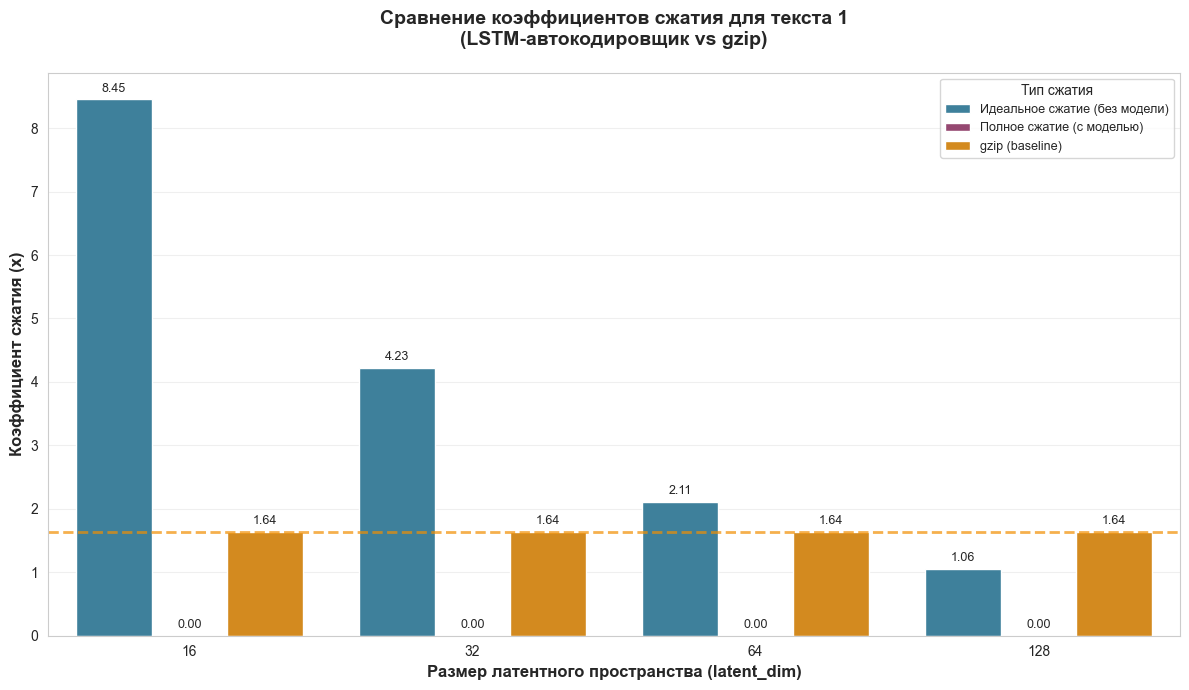

In [84]:
text1_results = df_all_results[df_all_results['text_index'] == 1].copy()

if len(text1_results) == 0:
    print("Нет данных для первого текста!")
else:
    print(f"Найдено результатов для текста 1: {len(text1_results)}")
    print(f"Доступные latent_dim: {text1_results['latent_dim'].tolist()}")
    
    plot_data = []
    
    for _, row in text1_results.iterrows():
        # Добавляем каждую метрику как отдельную строку
        plot_data.append({
            'latent_dim': row['latent_dim'],
            'Метрика': 'Идеальное сжатие (без модели)',
            'Коэффициент': row['compression_ideal']
        })
        plot_data.append({
            'latent_dim': row['latent_dim'],
            'Метрика': 'Полное сжатие (с моделью)',
            'Коэффициент': row['compression_full']
        })
        plot_data.append({
            'latent_dim': row['latent_dim'],
            'Метрика': 'gzip (baseline)',
            'Коэффициент': row['compression_gzip']
        })
    
    df_plot = pd.DataFrame(plot_data)

    plt.figure(figsize=(12, 7))
    
    # Настройка стиля
    sns.set_style("whitegrid")
    sns.set_palette("husl")
    
    # Столбчатая диаграмма с группировкой по latent_dim
    ax = sns.barplot(
        data=df_plot, 
        x='latent_dim', 
        y='Коэффициент', 
        hue='Метрика',
        palette={'Идеальное сжатие (без модели)': '#2E86AB', 
                 'Полное сжатие (с моделью)': '#A23B72', 
                 'gzip (baseline)': '#F18F01'}
    )
    
    # Добавление значений на столбцы
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=9, padding=3)
    
    # Настройка внешнего вида
    plt.title('Сравнение коэффициентов сжатия для текста 1\n(LSTM-автокодировщик vs gzip)', 
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Размер латентного пространства (latent_dim)', fontsize=12, fontweight='bold')
    plt.ylabel('Коэффициент сжатия (x)', fontsize=12, fontweight='bold')
    plt.legend(title='Тип сжатия', title_fontsize=10, fontsize=9, loc='upper right')
    
    # Добавление горизонтальной линии для gzip baseline
    gzip_value = text1_results.iloc[0]['compression_gzip']  # берём первое значение gzip
    plt.axhline(y=gzip_value, color='#F18F01', linestyle='--', linewidth=2, alpha=0.7, 
                label=f'gzip baseline ({gzip_value:.2f}x)')
    
    # Настройка сетки
    plt.grid(axis='y', alpha=0.3)
    
    # Оптимизация расположения
    plt.tight_layout()
    plt.show()

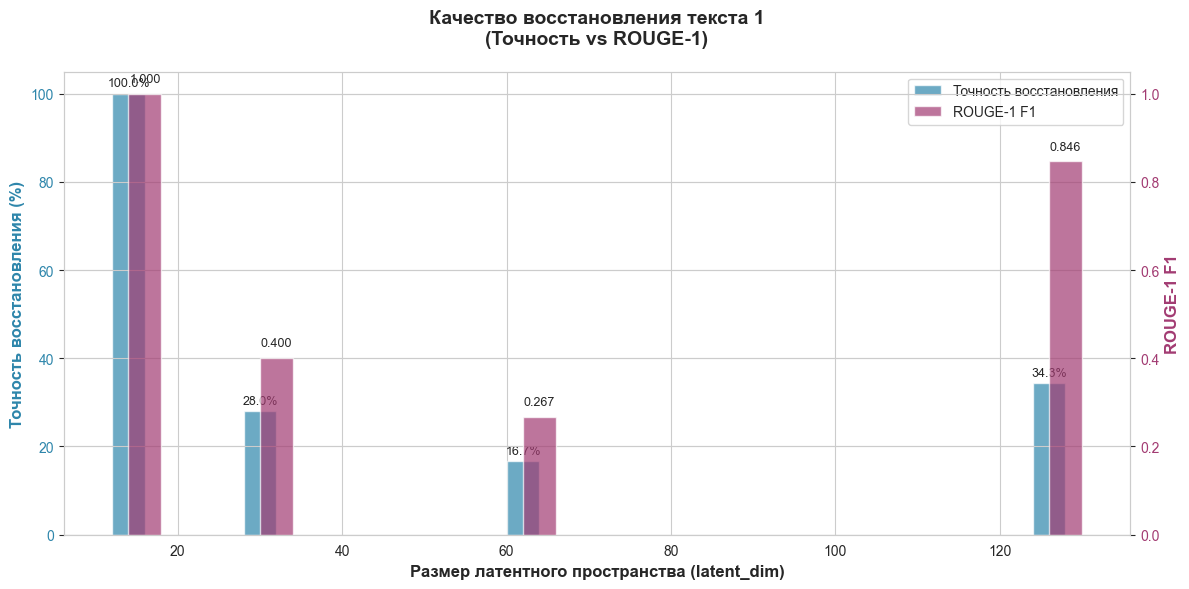

In [88]:
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # Создаём две оси Y
    ax2 = ax1.twinx()
    
    # Данные
    x = text1_results['latent_dim'].values
    
    # Столбцы для точности (левая ось)
    bars = ax1.bar(x - 2, text1_results['accuracy'] * 100, width=4, 
                   label='Точность восстановления', color='#2E86AB', alpha=0.7)
    
    # Столбцы для ROUGE (правая ось)
    line = ax2.bar(x, text1_results['rouge_1'], width=4, 
                     label='ROUGE-1 F1', color='#A23B72', alpha=0.7)
    
    # Настройка левой оси
    ax1.set_xlabel('Размер латентного пространства (latent_dim)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Точность восстановления (%)', fontsize=12, fontweight='bold', color='#2E86AB')
    ax1.tick_params(axis='y', labelcolor='#2E86AB')
    ax1.set_ylim(0, 105)
    
    # Настройка правой оси
    ax2.set_ylabel('ROUGE-1 F1', fontsize=12, fontweight='bold', color='#A23B72')
    ax2.tick_params(axis='y', labelcolor='#A23B72')
    ax2.set_ylim(0, 1.05)
    
    # Добавление значений на столбцы
    for bar, val in zip(bars, text1_results['accuracy'] * 100):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
    
    # Добавление значений на точки ROUGE
    for i, (xi, yi) in enumerate(zip(x, text1_results['rouge_1'])):
        ax2.text(xi, yi + 0.02, f'{yi:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.title('Качество восстановления текста 1\n(Точность vs ROUGE-1)', 
              fontsize=14, fontweight='bold', pad=20)
    
    # Объединение легенд
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    
    plt.tight_layout()
    plt.show()

## Выводы

Использование методов машинного обучения дает огромный оверхед относительно традиционных архиваторов - модель, требуемая для декодирования, занимает намного больше места, чем исходный текст целиком. При масштабе корпуса, с которым мы работали (300 символов), вес модели не "окупается" - в ~2 Мб, занимаемых переобученной моделью, восстанавливающей один образец текста, можно уместить весь текст "Войны и мира".

Тем не менее, LTSM-автокодировщик в данной реализации и при данной конфигурации входных данных оказался эффективным lossy-кодировщиком. При длине латентного вектора 16 худшая точность восстановления - 99,7%. При прочих длинах латентного вектора точность нестабильна, а идеальный коэффициент сжатия падает. Размер модели во всех экспериментах около 2 Мб.

Практическая применимость: В текущем виде - слабая. Полученный алгоритм сжатия требует больших вычислительных затрат в бытовых условиях (использование ЦП вместо графического ускорителя), а "архив" на несколько порядков больше исходного файла. Хранение более универсальной модели в составе "архиватора" могло бы иметь больший смысл, но это требует пересмотра архитектуры и параметров модели.